# EDL_LDL vs SNEFY_LDL

Compares the two uncertainty-aware LDL methods in this library on `Human_Gene` and `SJAFFE`. Both expose per-label variance via `predict(X, return_uncertainty=True)`.

In [ ]:
# # Ignore cache
%load_ext autoreload
%autoreload 2
from pyldl.algorithms import EDL_LDL, SNEFY_LDL, SA_BFGS, BEDL_LDL, AA_BP, Duo_LDL
from pyldl.utils import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import keras
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def fit_and_score(model_cls, X_train, D_train, X_test, D_test, label, **fit_kwargs):
    model = model_cls()
    model.fit(X_train, D_train, **fit_kwargs)
    scores = model.score(X_test, D_test, return_dict=True)
    print(f'--- {label} ---')
    for k, v in scores.items():
        print(f'{k}: {v:.4f}')
    return model

## Dataset 1: Human_Gene

In [ ]:
datasets = ['SJAFFE', 'SBU_3DFE', 'Human_Gene']

In [ ]:
X, D = load_dataset('SJAFFE')
X_train, X_test, D_train, D_test = train_test_split(X, D, val test_size=.1, random_state=0)
X.shape, D.shape

((213, 243), (213, 6))

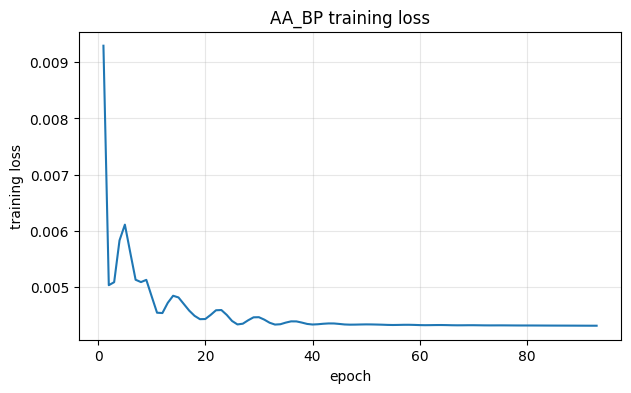

chebyshev: 0.1375
clark: 0.4733
canberra: 1.0095
kl_divergence: 0.0922
cosine: 0.9130
intersection: 0.8253


In [61]:
import keras
import matplotlib.pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.losses = []

    def on_epoch_end(self, epoch, logs=None):
        if logs and 'loss' in logs:
            self.losses.append(float(logs['loss']))   # cast in case it's a tf.Tensor


history = LossHistory()

from pyldl.utils import LDLEarlyStopping

bp = AA_BP()
bp.fit(
    X_train, D_train,
    epochs=2500, batch_size=256,
    X_val=X_test, D_val=D_test,                # <-- needed for validation-based stopping
    optimizer=keras.optimizers.AdamW(learning_rate=1e-2, weight_decay=1e-4),
    callbacks=[
        LDLEarlyStopping(monitor='kl_divergence', patience=60),
        history,
    ],
)


plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history.losses) + 1), history.losses)
plt.xlabel('epoch'); plt.ylabel('training loss')
plt.title('AA_BP training loss')
plt.grid(True, alpha=0.3)
plt.show()

scores = bp.score(X_test, D_test, return_dict=True)
for k, v in scores.items():
    print(f'{k}: {v:.4f}')


In [60]:
scores

{'chebyshev': 0.1378861904965852,
 'clark': 0.475514502838692,
 'canberra': 1.0051423536573187,
 'kl_divergence': 0.09099441121916363,
 'cosine': 0.9138582216616129,
 'intersection': 0.8260234373427935}

In [ ]:
bp = AA_BP()
bp.fit(X_train, D_train, epochs=100, batch_size=256)
scores = bp.score(X_test, D_test, return_dict=True)
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

chebyshev: 0.1923
clark: 0.9035
canberra: 1.9299
kl_divergence: 0.3003
cosine: 0.7867
intersection: 0.6876


In [58]:
sa_bfgs_mod = SA_BFGS()
sa_bfgs_mod.fit(X_train, D_train)
scores = sa_bfgs_mod.score(X_test, D_test, return_dict=True)
print(f'--- {sa_bfgs_mod.__class__.__name__} ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- SA_BFGS ---
chebyshev: 0.0911
clark: 0.3435
canberra: 0.6939
kl_divergence: 0.0440
cosine: 0.9603
intersection: 0.8845


In [27]:
bp

AA_BP()

AA_BP()

In [28]:
bp = AA_BP()
bp.fit(X_train, D_train, epochs=100, batch_size=256)
scores = bp.score(X_test, D_test, return_dict=True)
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

chebyshev: 0.1636
clark: 0.6038
canberra: 1.2382
kl_divergence: 0.1711
cosine: 0.8669
intersection: 0.7877


In [9]:
duo_ldl

,n_hidden,64


In [5]:
duo_ldl = Duo_LDL(n_hidden=64)
duo_ldl.fit(X_train, D_train, epochs=100)
scores = duo_ldl.score(X_test, D_test, return_dict=True)
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

chebyshev: 0.1382
clark: 0.4737
canberra: 1.0080
kl_divergence: 0.0929
cosine: 0.9124
intersection: 0.8255


In [10]:
edl_ll

,n_hidden,64
,n_latent,32


In [6]:
edl_ll = EDL_LDL(n_hidden=64)
edl_ll.fit(X_train, D_train, loss_type='loglikelihood', epochs=100, batch_size=256)
scores = edl_ll.score(X_test, D_test, return_dict=True)
print(f'--- EDL_LDL on Human_Gene ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- EDL_LDL on Human_Gene ---
chebyshev: 0.1386
clark: 0.4727
canberra: 1.0187
kl_divergence: 0.0953
cosine: 0.9107
intersection: 0.8238


In [22]:
bedl_ll = BEDL_LDL(n_hidden=64)
bedl_ll.fit(X_train, D_train, loss_type='loglikelihood', epochs=100, batch_size=256)
scores = bedl_ll.score(X_test, D_test, return_dict=True)
print(f'--- BEDL_LDL on Human_Gene ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- BEDL_LDL on Human_Gene ---
chebyshev: 0.1302
clark: 0.3991
canberra: 0.8737
kl_divergence: 0.0793
cosine: 0.9234
intersection: 0.8441


In [6]:
edl_bayes = EDL_LDL(n_hidden=64, n_latent=None)
edl_bayes.fit(X_train, D_train, loss_type='bayes_mse', epochs=100, batch_size=256)
scores = edl_bayes.score(X_test, D_test, return_dict=True)
print(f'--- EDL_LDL on Human_Gene ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')


--- EDL_LDL on Human_Gene ---
chebyshev: 0.1384
clark: 0.4746
canberra: 1.0087
kl_divergence: 0.0935
cosine: 0.9119
intersection: 0.8254


In [7]:
bedl_ll = BEDL_LDL(n_hidden=64)
bedl_ll.fit(X_train, D_train, loss_type='bayes_mse', epochs=100, batch_size=256)
scores = bedl_ll.score(X_test, D_test, return_dict=True)
print(f'--- BEDL_LDL on Human_Gene ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- BEDL_LDL on Human_Gene ---
chebyshev: 0.1396
clark: 0.4759
canberra: 1.0098
kl_divergence: 0.0935
cosine: 0.9119
intersection: 0.8252


In [32]:
sa_bfgs_mod = SA_BFGS()
sa_bfgs_mod.fit(X_train, D_train)
scores = sa_bfgs_mod.score(X_test, D_test, return_dict=True)
print(f'--- {sa_bfgs_mod.__class__.__name__} ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- SA_BFGS ---
chebyshev: 0.0867
clark: 0.3258
canberra: 0.6594
kl_divergence: 0.0383
cosine: 0.9654
intersection: 0.8895


In [23]:
SNEFY_LDL(n_hidden=64)

,n_hidden,64
,n_latent,32


In [31]:
snefy_model = SNEFY_LDL()
snefy_model.fit(X_train, D_train, epochs=100)
scores = snefy_model.score(X_test, D_test, return_dict=True)
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

chebyshev: 0.3269
clark: 1.6052
canberra: 3.5132
kl_divergence: 1.1967
cosine: 0.6004
intersection: 0.4938


## Dataset 2: SJAFFE

In [9]:
X, D = load_dataset('SJAFFE')
X_train, X_test, D_train, D_test = train_test_split(X, D, test_size=.1, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X.shape, D.shape

((213, 243), (213, 6))

In [10]:
edl_sj = fit_and_score(EDL_LDL, X_train, D_train, X_test, D_test,
                       'EDL_LDL on SJAFFE', epochs=500)

--- EDL_LDL on SJAFFE ---
chebyshev: 0.0765
clark: 0.3265
canberra: 0.6536
kl_divergence: 0.0431
cosine: 0.9670
intersection: 0.8973


In [11]:
snefy_sj = fit_and_score(SNEFY_LDL, X_train, D_train, X_test, D_test,
                         'SNEFY_LDL on SJAFFE', epochs=500)

--- SNEFY_LDL on SJAFFE ---
chebyshev: 0.2554
clark: 1.2122
canberra: 2.4362
kl_divergence: 0.6545
cosine: 0.7589
intersection: 0.6550


## Uncertainty output

Both methods expose per-label variance via `predict(X, return_uncertainty=True)`. EDL additionally returns a scalar total-evidence uncertainty `u = K / alpha_0` per sample.

In [12]:
D_pred, variance, u = edl_sj.predict(X_test[:3], return_uncertainty=True)
print('EDL_LDL on SJAFFE (first 3 test samples):')
print(f'mean prediction:\n{D_pred}')
print(f'per-label variance:\n{variance}')
print(f'total-evidence uncertainty u = K/alpha_0: {u}')

EDL_LDL on SJAFFE (first 3 test samples):
mean prediction:
[[0.30543625 0.13934675 0.15138027 0.14387538 0.12794092 0.1320204 ]
 [0.00551136 0.16851525 0.1222982  0.19630179 0.329817   0.17755641]
 [0.19781828 0.1553675  0.20636818 0.1575953  0.154704   0.1281468 ]]
per-label variance:
[[4.7451188e-04 2.6824980e-04 2.8734043e-04 2.7551028e-04 2.4955699e-04
  2.5630961e-04]
 [2.9687964e-05 7.5895322e-04 5.8141805e-04 8.5455237e-04 1.1972585e-03
  7.9097715e-04]
 [6.4390770e-04 5.3249119e-04 6.6457846e-04 5.3870189e-04 5.3063373e-04
  4.5335203e-04]]
total-evidence uncertainty u = K/alpha_0: [0.01345049 0.0326762  0.02444565]


In [13]:
D_pred, variance = snefy_sj.predict(X_test[:3], return_uncertainty=True)
print('SNEFY_LDL on SJAFFE (first 3 test samples):')
print(f'mean prediction:\n{D_pred}')
print(f'per-label variance:\n{variance}')

SNEFY_LDL on SJAFFE (first 3 test samples):
mean prediction:
[[0.03455068 0.02941382 0.15616381 0.2476444  0.19934878 0.33287862]
 [0.00200352 0.21167813 0.06551932 0.25983348 0.08351786 0.3774477 ]
 [0.00459895 0.06788299 0.24967228 0.21040873 0.1593737  0.30806324]]
per-label variance:
[[0.01805111 0.01069583 0.01593196 0.02560525 0.02194462 0.03251725]
 [0.00046322 0.03109189 0.01074    0.05381758 0.01652116 0.04592818]
 [0.00168825 0.01817407 0.10208035 0.04417101 0.02361566 0.04855093]]
